In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Méthode du gradient pour f(x) = 0.5*x'*Q*x-c'*x+p
def GradientMethodQuadraticF(Q,c,p,x0,maxiter,choixpas='exact'):
  x = x0.copy()

  valeurspropres, vecteurspropres = np.linalg.eig(Q)
  L = np.max(valeurspropres) #constante de Lipschitz pour le cas quadratique
  fobj = np.zeros(maxiter)

  for k in range(maxiter):
    grad = Q@x-c
    d = -grad #direction de recherche

    if choixpas =='exact':
      alpha = (d@d)/(d@(Q@d)) #dans le cas quadratique, on peut calculer le meilleur ?
    if choixpas=='lipschitz':
      alpha = 1/L #pas constant au fur et à mesure des itérations

    x = x+alpha*d
    fobj[k] = 0.5*x@Q@x-c@x+p

    if np.linalg.norm(grad) < 1e-5:
      print("J'arrête car on a convergé vers un point stationnaire")
      break

  return x, fobj, k

[ 0.55       -0.332      -0.64952    -0.7638272  -0.80497779 -0.81979201
 -0.82512512 -0.82704504 -0.82773622 -0.82798504 -0.82807461 -0.82810686
 -0.82811847 -0.82812265 -0.82812415 -0.8281247  -0.82812489 -0.82812496
 -0.82812499 -0.82812499 -0.828125   -0.828125   -0.828125   -0.828125
 -0.828125  ]


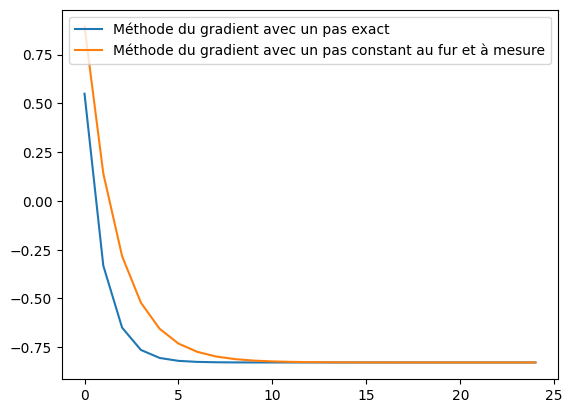

In [3]:
#Premier exemple
Q = np.array([[10,-6],[-6,10]])
c = np.array([4,-3])
p = 0

#Itéré initial
x0 = np.array([1.0,1.0])

#Appels des méthodes
xexact, fexact, kexact = GradientMethodQuadraticF(Q,c,p,x0,25,'exact')
xlipschitz, flipschitz, klipschitz = GradientMethodQuadraticF(Q,c,p,x0,25,'lipschitz')

print(fexact)
plt.plot(fexact, label="Méthode du gradient avec un pas exact")
plt.plot(flipschitz, label="Méthode du gradient avec un pas constant au fur et à mesure")
plt.legend()
plt.show()

J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé v

C:\Users\maxim\AppData\Local\Temp\ipykernel_30616\3224614430.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  fobj[k] = 0.5*x@Q@x-c@x+p


J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé vers un point stationnaire
J'arrête car on a convergé v

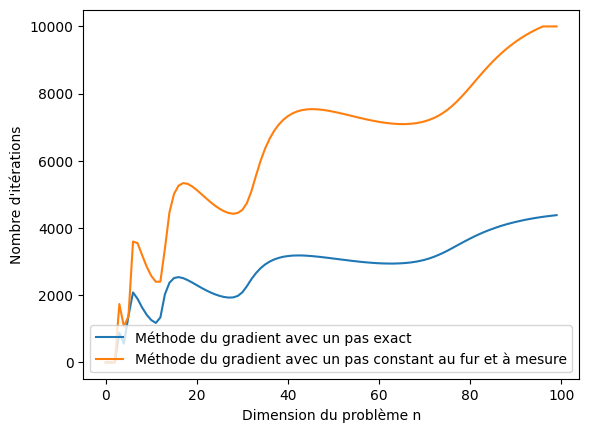

In [4]:
#Utilisons les matrices de Wilbert pour jouer sur la vitesse de convergence
#(ces matrices ont un mauvais conditionnement)
#(plus la dimension est importante, plus le conditionnement est mauvais

#ERREUR à corriger on est sensé avoir 2 zigzags vers l'infini positif

from scipy.linalg import hilbert

nbiteresexact = np.zeros(100)
nbiteresconst = np.zeros(100)

for n in range(3,100):
  Q = hilbert(n)
  c = np.zeros(n)
  p = 0
  x0 = np.ones(n)

  xexact, fexact, kexact = GradientMethodQuadraticF(Q,c,p,x0,10**4,'exact')
  xconst, fconst, kconst = GradientMethodQuadraticF(Q,c,p,x0,10**4,'lipschitz')

  nbiteresexact[n] = kexact
  nbiteresconst[n] = kconst

plt.plot(nbiteresexact, label="Méthode du gradient avec un pas exact")
plt.plot(nbiteresconst, label="Méthode du gradient avec un pas constant au fur et à mesure")
plt.legend()
plt.xlabel("Dimension du problème n")
plt.ylabel("Nombre d'itérations")
plt.show()

In [5]:
def fslides(x):
  f = (x[0]+x[1])**4 - 2*(x[0]+x[1])**2+1
  g = np.array([4*(x[0]+x[1])**3-4*(x[0]+x[1]),4*(x[0]+x[1])**3-4*(x[0]+x[1])])
  return f, g

#Test de ma fonction fslides :
x = np.array([0.25,0.25])
d = np.array([1.0,1.0])

f, g = fslides(x)
print(f"En x = {x}, on a f = {f} et gradient g = {g}".format(x=x,f=f,g=g))
print(f"d = {d} est une direction de descente car d*g = {d@g} est négatif")

En x = [0.25 0.25], on a f = 0.5625 et gradient g = [-1.5 -1.5]
d = [1. 1.] est une direction de descente car d*g = -3.0 est négatif


In [6]:
#Cette fonction w1 vérifie si la condition de Wolfe 1 est vérifiée pour un alpha donné
def w1(fct, x, d, alpha, beta1=1e-4):
  f1,g1 = fct(x+alpha*d)
  f0,g0 = fct(x)
  return f1 <= f0+beta1*alpha*(d@g0) + 1e-9

#Cette fonction w2 vérifie si la condition de Wolfe 2 est vérifiée pour un alpha donné
def w2(fct, x, d, alpha, beta2=0.9):
  f1,g1 = fct(x+alpha*d)
  f0,g0 = fct(x)
  return d@g1 >= beta2*d@g0

alpha = 0.24
outw1 = w1(fslides,x,d,alpha)
outw2 = w2(fslides,x,d,alpha)
print(f"alpha = {alpha}")
print(f"w1({alpha}) = {outw1}")
print(f"w2({alpha}) = {outw2}")

alpha = 0.24
w1(0.24) = True
w2(0.24) = True


In [7]:
def wolfebissetion(fct, x, d, alpha0):
  aleft = 0
  aright = np.Inf
  alpha = alpha0
  while True:
    print(f"Debut : aleft = {aleft}, aright = {aright}, et alpha = {alpha}")
    if w1(fct,x,d,alpha) and w2(fct,x,d,alpha):
      break
    if not w1(fct,x,d,alpha): #ça veut dire qu'on est trop loin
      aright = alpha          #on bouge la bornde de droite vers la gauche
      alpha = (aleft+aright)/2
    elif not w2(fct,x,d,alpha): #ça veut dire qu'on est trop loin
      aleft = alpha                #on bouge la borne de gauche vers la droite
      if aright < np.Inf:
        alpha = (aleft+aright)/2
      else:
        alpha = 2*alpha #le 2 est arbitraire
    print(f"Fin : aleft = {aleft}, aright = {aright}, et alpha = {alpha}")
  return alpha

alpha0 = 1e-6
alphaidentitfie = wolfebissetion(fslides,x,d,alpha0)
print(f"alpha identifié = {alphaidentitfie}")

AttributeError: `np.Inf` was removed in the NumPy 2.0 release. Use `np.inf` instead.

In [ ]:
def methgradient(fct,x,maxiter):
  x = x0.copy()
  alpha0=0.05
  fobj=np.zeros(maxiter)
  for k in range(maxiter):
    f,g = fct(x)
    d=-g
    alpha=wolfebissetion(fct,x,d,alpha0)
    x=x+alpha*d  #calcul du nouvel itéré

    f,g = fct(x)
    fobj[k] = f
    print(f"k={k}, x={x} et g = {g}")
    if np.linalg.norm(g) < 1e-9:

      break
  return x,fobj[:k]

In [ ]:
x0 = np.array([1,1])
maxiter=30

xgo,fogd = methgradient(fslides,x0,maxiter)
plt.plot(fogd)
plt.xlabel("Nombre d'itérations")
plt.ylabel("Valeur de la fonction objectif")
plt.show()

In [ ]:
def methgradient2(fct,x,maxiter):
  x = x0.copy()
  xprec = x0.copy()
  alpha0=0.05
  fobj=np.zeros(maxiter)
  for k in range(maxiter):
    beta = k/(k+3) #paul tseng
    y = x+beta*(x-xprec)


    f,g = fct(x)
    d=-g
    alpha=wolfebissetion(fct,x,d,alpha0)
    xprec=x.copy()
    x=x+alpha*d  #calcul du nouvel itéré

    f,g = fct(x)
    fobj[k] = f
    print(f"k={k}, x={x} et g = {g}")
    if np.linalg.norm(g) < 1e-9:

      break
  return x,fobj[:k]

In [ ]:
x0 = np.array([1,1])
maxiter=30

xgd,fgd = methgradient2(fslides,x0,maxiter)
plt.plot(fgd)
plt.xlabel("Nombre d'itérations")
plt.ylabel("Valeur de la fonction objectif")
plt.show()